# Day 13 — Logistic Regression baseline

First model, and the yardstick every later model must beat. Evaluated on the validation set only; the test set stays untouched until the final comparison.

In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print(os.getcwd())

c:\Semester 7\Project Iseng\IDX-ML-Lab


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

from idxlab.clean import clean_ticker_data
from idxlab.config import load_config
from idxlab.data import DataLoader
from idxlab.evaluation import evaluate_classifier
from idxlab.logging_setup import setup_logging
from idxlab.split import build_dataset, time_based_split

In [3]:
cfg = load_config()
setup_logging(cfg.log_level)

loader = DataLoader.from_config(cfg)
raw = loader.load_all()
bbca = clean_ticker_data(raw["BBCA.JK"])

dataset = build_dataset(bbca)
splits = time_based_split(dataset, train_size=0.7, val_size=0.15)

for name, part in [("train", splits.train), ("val", splits.val), ("test", splits.test)]:
    print(f"{name:5s} {len(part):4d} rows {part.index.min().date()} -> {part.index.max().date()}")

10:24:01 | INFO     | idxlab.data | Cache hit for BBCA.JK (data\raw\BBCA_JK.parquet)
10:24:01 | INFO     | idxlab.data | Cache hit for BBRI.JK (data\raw\BBRI_JK.parquet)
10:24:01 | INFO     | idxlab.data | Cache hit for TLKM.JK (data\raw\TLKM_JK.parquet)
10:24:01 | INFO     | idxlab.data | Cache hit for ASII.JK (data\raw\ASII_JK.parquet)
10:24:01 | INFO     | idxlab.data | Cache hit for UNVR.JK (data\raw\UNVR_JK.parquet)


train  595 rows 2023-01-30 -> 2025-08-08
val    127 rows 2025-08-11 -> 2026-02-12
test   128 rows 2026-02-13 -> 2026-08-28


In [4]:
LABEL_COLUMNS = ["forward_return", "direction"]

feature_cols = [c for c in dataset if c not in LABEL_COLUMNS] 

assert len(feature_cols) == 12
assert not set(LABEL_COLUMNS) & set(feature_cols), "label bocor ke fitur!"

X_train, y_train = splits.train[feature_cols], splits.train["direction"].astype(int)
X_val, y_val = splits.val[feature_cols], splits.val["direction"].astype(int)

print(f"Share of up-days  train: {y_train.mean():.3f}   val: {y_val.mean():.3f}")

Share of up-days  train: 0.435   val: 0.402


In [5]:
# TODO 3: DummyClassifier yang selalu menebak kelas terbanyak di train
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_val)
dummy_proba = dummy.predict_proba(X_val)[:, 1]

In [7]:
# TODO 4: Pipeline dua langkah: (1) standardisasi fitur, (2) logistic regression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

# TODO 5: latih model. Pakai data yang mana?
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['sma','ema','rsi',...,'atr','obv','momentum']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [8]:
train_pred = model.predict(X_train)
train_proba = model.predict_proba(X_train)[:, 1]

val_pred = model.predict(X_val)
# TODO 6: probabilitas kelas 1 (naik) untuk data validasi
val_proba = model.predict_proba(X_val)[:, 1]

In [9]:
results = pd.DataFrame({
    "dummy (val)": evaluate_classifier(y_val, dummy_pred, dummy_proba),
    "logreg (train)": evaluate_classifier(y_train, train_pred, train_proba),
    "logreg (val)": evaluate_classifier(y_val, val_pred, val_proba),
}).round(3)
results

,dummy (val),logreg (train),logreg (val)
accuracy,0.598,0.605,0.583
precision,0.000,0.581,0.458
recall,0.000,0.332,0.216
f1,0.000,0.423,0.293
roc_auc,0.500,0.607,0.571


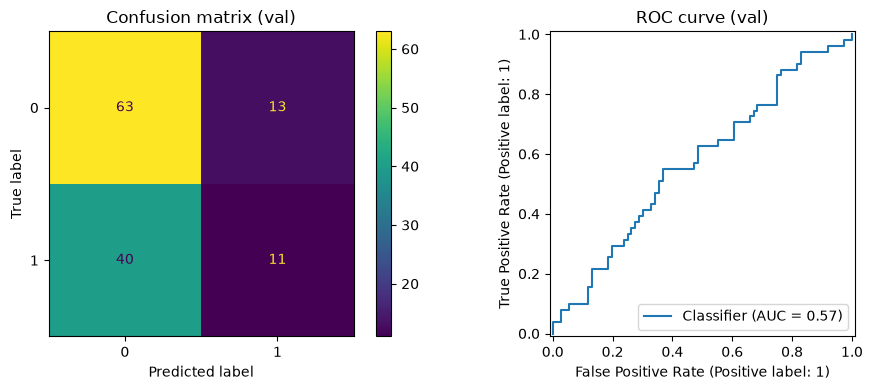

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# TODO 7: confusion matrix dan kurva ROC untuk validation set
ConfusionMatrixDisplay.from_predictions(y_val, val_pred, ax=axes[0])
RocCurveDisplay.from_predictions(y_val, val_proba, ax=axes[1])

axes[0].set_title("Confusion matrix (val)")
axes[1].set_title("ROC curve (val)")
plt.tight_layout()
plt.show()

In [11]:
coefs = pd.Series(model.named_steps["clf"].coef_[0], index=feature_cols).sort_values()
coefs

rsi              -0.480003
momentum         -0.288777
bb_lower         -0.135043
sma              -0.101767
bb_upper         -0.065160
ema               0.038376
atr               0.112753
bb_width          0.148453
macd_signal       0.161567
obv               0.192609
macd              0.242034
macd_histogram    0.288611
dtype: float64

In [12]:
val_scaled = pd.DataFrame(model[:-1].transform(X_val), columns=feature_cols, index=X_val.index)
val_scaled.abs().max().round(1)

sma               2.2
ema               2.3
rsi               3.2
macd              2.5
macd_signal       2.2
macd_histogram    4.3
bb_upper          2.1
bb_lower          2.8
bb_width          5.3
atr               1.9
obv               6.2
momentum          5.5
dtype: float64